In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.cm as cm
import random
import scipy.signal as sp
import seaborn as sns
from IPython.display import display
from scipy.stats import kruskal

### Combine

In [2]:
Data=r"F:\data\Code\Features 2\acc\ACC Final\features"
files_in_directory = os.listdir(Data)
print(files_in_directory)

['ACC100.csv', 'ACC110.csv', 'ACC118.csv', 'ACC122.csv', 'ACC123.csv', 'ACC124.csv', 'ACC125.csv', 'ACC75.csv', 'ACC76.csv', 'ACC77.csv', 'ACC83.csv', 'ACC84.csv', 'ACC85.csv', 'ACC86.csv', 'ACC88.csv', 'ACC89.csv', 'ACC93.csv', 'ACC94.csv', 'ACC95.csv', 'ACC96.csv']


In [3]:
all_files = []
for filename in files_in_directory:
    if filename.endswith('.csv'):
        filepath = os.path.join(Data, filename)
        df = pd.read_csv(filepath)
        all_files.append(df)

combined_df = pd.concat(all_files, ignore_index=True)
print("Combined DataFrame created with shape:", combined_df.shape)

Combined DataFrame created with shape: (42907, 20)


In [4]:
output_filepath = os.path.join(Data, 'combined_data.csv')
combined_df.to_csv(output_filepath, index=False)
print(f"Combined data saved to: {output_filepath}")

Combined data saved to: F:\data\Code\Features 2\acc\ACC Final\features\combined_data.csv


In [6]:
ACC=pd.read_csv(r"F:\data\Code\Features 2\acc\ACC Final\features\combined_data.csv")

In [7]:
Label_counts = ACC['label'].value_counts().reset_index()
Label_counts.columns = ['Label', 'Count']
Label_counts

,Label,Count
0,normal,37089
1,preictal,2828
2,postictal,2260
3,ictal,730


### Analysis

#### Ranges

In [2]:
def Analysis_Feature(df, label_col='label', exclude_cols=None):

    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = ['subject', 'run', 'window_id', 'start_time', 'end_time','preictal_ratio', 'ictal_ratio', 'postictal_ratio', 'window_length', 'sfreq',]
    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]
    print(f"Analyzing {len(features)} numeric features: {features}\n")

    for feature in features:
        ranges_list = []

        for label in df[label_col].unique():
            values = df[df[label_col] == label][feature].dropna()
            if len(values) == 0:
                continue
            stats = {
                'Label': label,
                'Min': values.min(),
                'Max': values.max(),
                'Mean': values.mean(),
                'Std': values.std(),
                'Median': values.median(),
                '25th_percentile': values.quantile(0.25),
                '75th_percentile': values.quantile(0.75)
            }
            ranges_list.append(stats)

        df_feature = pd.DataFrame(ranges_list)

        df_feature = df_feature.sort_values(by='Mean', ascending=False).reset_index(drop=True)

        print(f"==== Feature: {feature} ====")
        display(df_feature)

In [3]:
def Full_Analysis(df, label_col='label', exclude_cols=None):

    if label_col not in df.columns:
        raise ValueError(f"'{label_col}' not found in DataFrame")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    exclude = ['subject', 'run', 'encoded_label', 'sfreq','window_id',
               'start_time', 'end_time','preictal_ratio', 'ictal_ratio', 'postictal_ratio', 'window_length', 'sfreq',]

    if exclude_cols:
        exclude.extend(exclude_cols)

    features = [col for col in numeric_cols if col not in exclude]

    results = []

    for feature in features:
        groups = [
            df[df[label_col] == lbl][feature].dropna()
            for lbl in df[label_col].unique()
        ]

        if all(len(g) > 0 for g in groups):
            stat, p = kruskal(*groups)
            results.append({
                'Feature': feature,
                'H-stat': stat,
                'p-value': p
            })
        else:
            results.append({
                'Feature': feature,
                'H-stat': np.nan,
                'p-value': np.nan
            })

    df_stats = pd.DataFrame(results).sort_values('p-value')

    return df_stats

#### VIsualize Analysis

In [4]:
def Plot_Boxplots(df, label_col='label'):
    features = [ 'activity_score', 'rms_mag', 'std_mag']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.boxplot(x=label_col, y=feat, data=df, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel('')
        axs[i].set_ylabel(feat)

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Boxplots of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [5]:
def Plot_Violin(df, label_col='label', bins=30):

    features = [ 'activity_score', 'rms_mag', 'std_mag']


    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.violinplot(x=label_col, y=feat, data=df, ax=axs[i], inner='quartile')
        axs[i].set_title(f'Violin of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Violines of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [6]:
def Plot_Distribution(df, label_col='label'):
    features = ['activity_score', 'rms_mag', 'std_mag']

    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.kdeplot(data=df, x=feat, hue=label_col, fill=True, ax=axs[i])
        axs[i].set_title(f'{feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Density')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Distributions of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [7]:
def Plot_Histograms(df, label_col='label', bins=30):

    features = [ 'activity_score', 'rms_mag', 'std_mag']


    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axs = axs.flatten()

    for i, feat in enumerate(features):
        sns.histplot(data=df, x=feat, hue=label_col, kde=False, bins=bins, ax=axs[i], alpha=0.7)
        axs[i].set_title(f'Histogram of {feat}', fontsize=11)
        axs[i].set_xlabel(feat)
        axs[i].set_ylabel('Count')

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Histograms of Features", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [8]:
def Plot_Correlation(df):

    num_cols = ['activity_score', 'rms_mag', 'std_mag']


    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Features")
    plt.tight_layout()
    plt.show()

#### Visualize

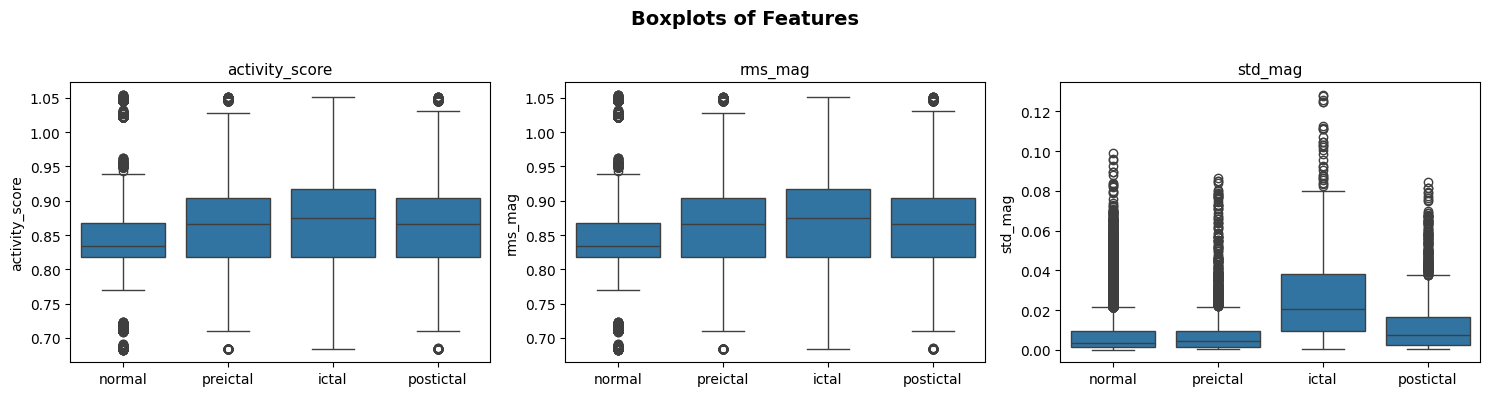

In [25]:
Plot_Boxplots(ACC)

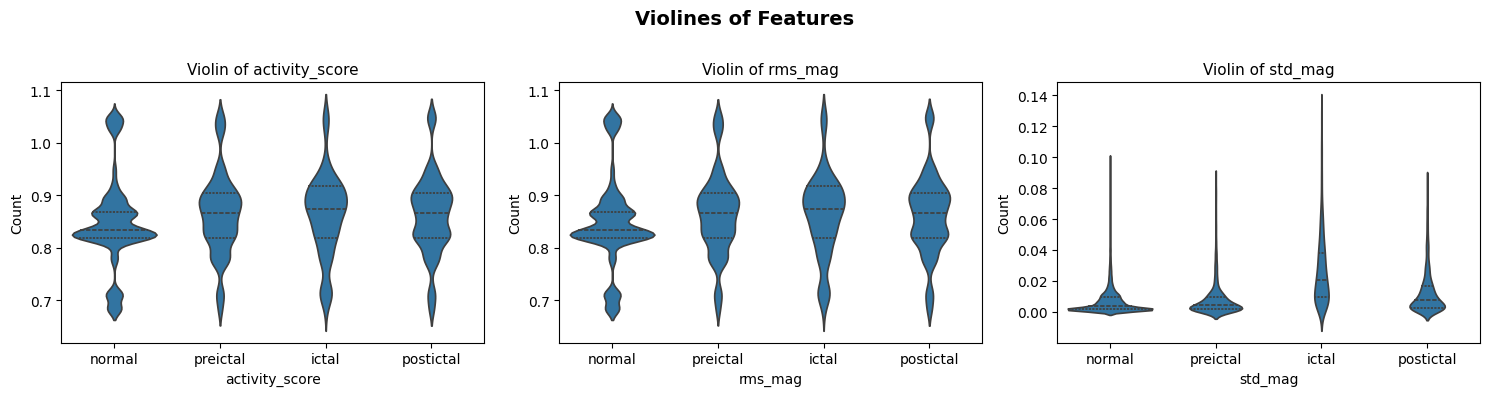

In [26]:
Plot_Violin(ACC)

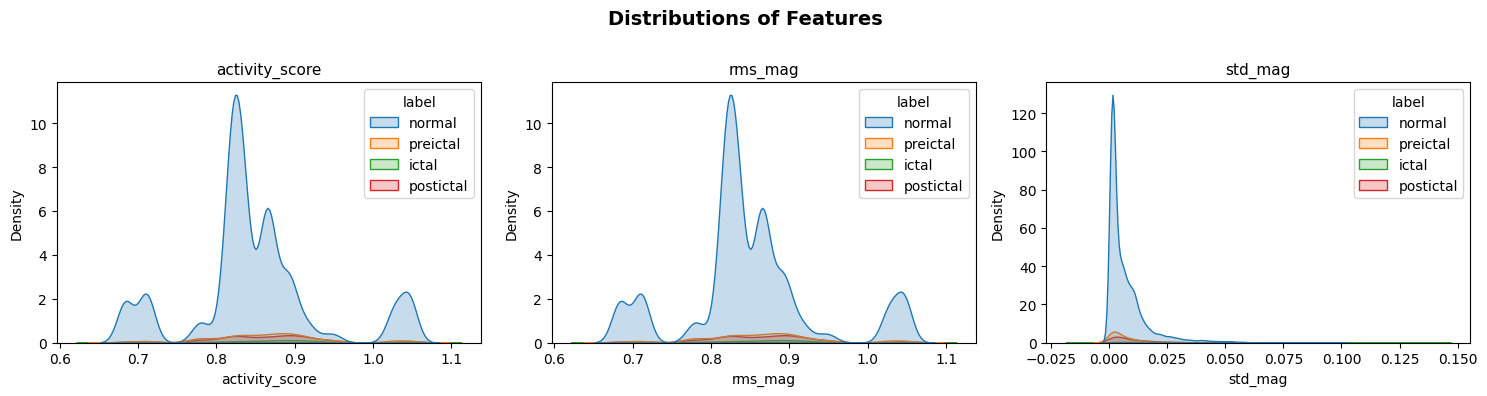

In [27]:
Plot_Distribution(ACC)

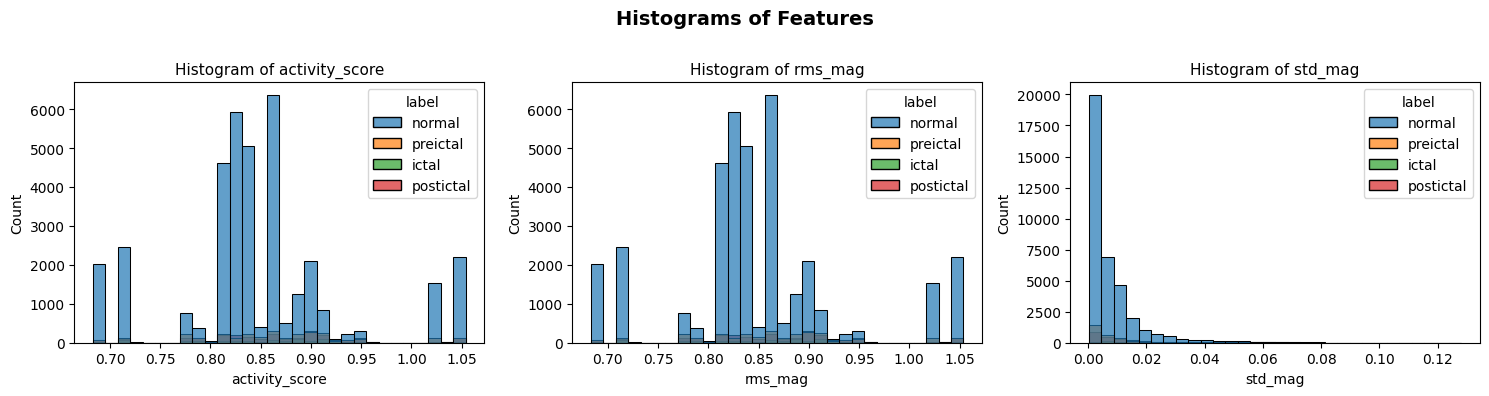

In [28]:
Plot_Histograms(ACC)

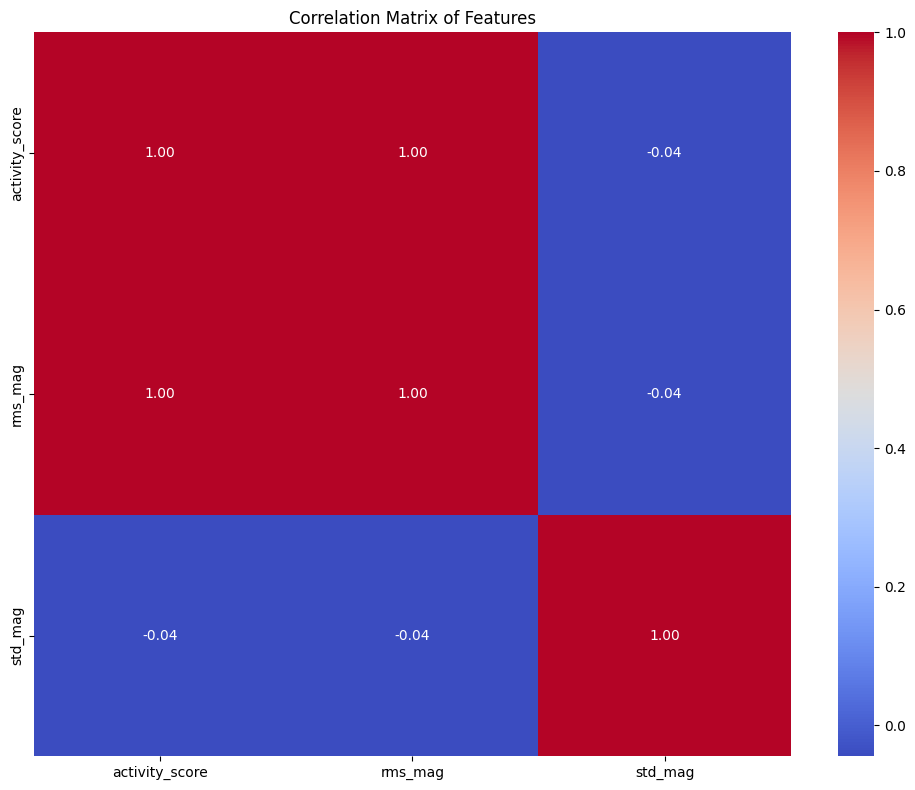

In [29]:
Plot_Correlation(ACC)

#### Numerical

In [9]:
ACC=pd.read_csv(r"F:\graduation project\data\Code\final\acc 60s 10min\features\combined_data.csv")

In [10]:
Analysis_Feature(ACC)

Analyzing 3 numeric features: ['activity_score', 'rms_mag', 'std_mag']

==== Feature: activity_score ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,preictal,0.683245,1.051208,0.864369,0.076822,0.865470,0.817541,0.904588
1,ictal,0.683256,1.050847,0.862267,0.077672,0.874420,0.818600,0.916853
2,postictal,0.683243,1.051735,0.862238,0.074473,0.866589,0.818637,0.904595
3,normal,0.683113,1.053920,0.847769,0.085274,0.834042,0.817455,0.867121


==== Feature: rms_mag ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,preictal,0.683245,1.051208,0.864369,0.076822,0.865470,0.817541,0.904588
1,ictal,0.683256,1.050847,0.862267,0.077672,0.874420,0.818600,0.916853
2,postictal,0.683243,1.051735,0.862238,0.074473,0.866589,0.818637,0.904595
3,normal,0.683113,1.053920,0.847769,0.085274,0.834042,0.817455,0.867121


==== Feature: std_mag ====


,Label,Min,Max,Mean,Std,Median,25th_percentile,75th_percentile
0,ictal,0.000275,0.128195,0.027239,0.023514,0.020518,0.009578,0.038029
1,postictal,0.000560,0.084340,0.012612,0.014169,0.007495,0.002651,0.016688
2,preictal,0.000298,0.086531,0.008370,0.011817,0.004324,0.001748,0.009793
3,normal,0.000215,0.098934,0.007238,0.009283,0.003740,0.001549,0.009486


In [11]:
Full_Analysis(ACC)

,Feature,H-stat,p-value
2,std_mag,1527.740837,0.000000e+00
0,activity_score,472.643362,4.045022e-102
1,rms_mag,472.643362,4.045022e-102
